# 11 Gene-Level Feature Importance from PC Models

For each qualifying pair, trace the PC + co-variate RF back to per-gene importance via `gene_j = Σ_i RF_imp_norm_i × |loading_norm(i,j)|`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from trace_path.config import Config
from trace_path.data import load_cache, build_confounder_matrix, variance_filter
from trace_path.labels import assign_donor_labels
from trace_path.models import make_rf_model, _auc_feature_selection, _compute_pc_covariate_aucs, _drop_covariate_aligned_pcs

Config.ensure_dirs()

X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()
X_conf = build_confounder_matrix(df_age, blood_subjid)

# Variance filter — same 20K genes as NB07 and NB10
X_wb_var, gene_var = variance_filter(X_wb)
print(f'Variance filter: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes')

gene_map_df = pd.read_csv(Config.EXPR_FILE, sep="\t", skiprows=2,
                           usecols=["Name", "Description"], nrows=60000)
gene_id_to_name = dict(zip(gene_map_df["Name"].astype(str),
                            gene_map_df["Description"].astype(str)))

# NB07 direct RF importance (for validation)
rf_fi = pd.read_csv(Config.TABLES_DIR / "rf_feature_importances.csv")

print(f"Expression: {X_wb_var.shape[0]} samples x {X_wb_var.shape[1]:,} genes")
print(f"Gene mapping: {len(gene_id_to_name):,}")
print(f"NB07 RF importance: {len(rf_fi)} rows")
# Genes whose symbol remains "ENSGxxxxx" (no proper HGNC name) are unannotated transcripts — drop everywhere downstream.
def named_only(imp_series):
    keep = [g for g in imp_series.index
            if not str(gene_id_to_name.get(g, g)).startswith("ENSG")]
    return imp_series.loc[keep]

## 11.1 — Filter Qualifying Models

From NB10: PC + co-variates AUC ≥ 0.60 and Δ ≥ 0.05.

In [2]:
AUC_THRESH = Config.AUC_THRESH
DELTA_THRESH = Config.DELTA_THRESH
N_PCS = 800
TOP_K_PCS = 100
TOP_N_GENES = 30

pc_results = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")

qualified_all = pc_results[
    (pc_results["auc_pc_conf"] >= AUC_THRESH) & (pc_results["delta_pc"] >= DELTA_THRESH)
].reset_index(drop=True)

print(f"Total pairs: {len(pc_results)}")
print(f"Qualifying (AUC >= {AUC_THRESH}, Δ >= {DELTA_THRESH}): {len(qualified_all)}")
print()
display(qualified_all[["tissue", "category", "auc_pc_conf", "delta_pc"]].sort_values("delta_pc", ascending=False))

Total pairs: 59
Qualifying (AUC >= 0.6, Δ >= 0.05): 4



,tissue,category,auc_pc_conf,delta_pc
0,Liver,cirrhosis,0.789920,0.214962
1,Liver,steatosis,0.665803,0.147674
2,Small Intestine - Terminal Ileum,nodularity,0.622219,0.080496
3,Lung,congestion,0.667069,0.053479


## 11.2 — Shared Functions

In [3]:
def run_cv_with_artifacts(X, y, groups, X_conf_sub,
                          n_pcs=N_PCS, top_k_pcs=TOP_K_PCS, tag=""):
    """Leak-free CV that returns PCA loadings + normalized RF importances per fold."""
    cv = StratifiedGroupKFold(n_splits=Config.N_SPLITS, shuffle=True,
                              random_state=Config.SEED)
    fold_artifacts = []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
        Xtr = X.iloc[tr]
        ytr = y.iloc[tr]

        scaler = StandardScaler()
        Xtr_scaled = scaler.fit_transform(Xtr)
        n_comp = min(n_pcs, Xtr_scaled.shape[0] - 1, Xtr_scaled.shape[1])
        pca = PCA(n_components=n_comp, random_state=Config.SEED)
        Xtr_pcs = pca.fit_transform(Xtr_scaled)

        pc_cols = [f"PC{i+1}" for i in range(n_comp)]
        Xtr_pcs = pd.DataFrame(Xtr_pcs, columns=pc_cols, index=Xtr.index)

        # Covariate-orthogonal PC filter (Sanju spec)
        X_covar_tr = X_conf_sub.iloc[tr]
        cov_aucs_pc = _compute_pc_covariate_aucs(Xtr_pcs, X_covar_tr)
        keep_mask_pc = _drop_covariate_aligned_pcs(cov_aucs_pc, Config.COVARIATE_ORTHO_AUC_THRESH)
        Xtr_pcs_filt = Xtr_pcs.loc[:, keep_mask_pc]

        top_pcs = _auc_feature_selection(Xtr_pcs_filt, ytr, top_k=min(top_k_pcs, Xtr_pcs_filt.shape[1]))
        selected_idx = [int(c.replace("PC", "")) - 1 for c in top_pcs]

        Xtr_sel = pd.concat([Xtr_pcs[top_pcs], X_conf_sub.iloc[tr]], axis=1)

        model = make_rf_model()
        model.fit(Xtr_sel, ytr)

        # Step 1: Slice PC importances and renormalize to sum to 1
        n_pc_features = len(top_pcs)
        rf_imp_pcs = model.feature_importances_[:n_pc_features].copy()
        rf_imp_pcs = rf_imp_pcs / rf_imp_pcs.sum()

        fold_artifacts.append({
            "loadings": pca.components_,
            "selected_idx": selected_idx,
            "rf_imp_pcs": rf_imp_pcs,
        })

    print(f"  {tag}: collected artifacts from {len(fold_artifacts)} folds")
    return fold_artifacts

def compute_gene_importance(artifacts, gene_columns):
    """Compute normalized gene importance from fold artifacts."""
    n_genes = len(gene_columns)
    imp = np.zeros(n_genes)

    for art in artifacts:
        sel_loadings = art["loadings"][art["selected_idx"], :]
        rf_imp = art["rf_imp_pcs"]

        # Step 2: normalize |loadings| per PC so each row sums to 1
        abs_loadings = np.abs(sel_loadings)
        row_sums = abs_loadings.sum(axis=1, keepdims=True)
        abs_loadings_norm = abs_loadings / row_sums

        imp += (rf_imp[:, None] * abs_loadings_norm).sum(axis=0)

    imp /= len(artifacts)
    return pd.Series(imp, index=gene_columns)

def run_single_pair(tissue, category):
    """Run artifact collection + gene importance for one tissue|category pair."""
    y, _, n_pos, n_neg = assign_donor_labels(
        df_meta_url, tissue, category, blood_subjid
    )
    keep = y.notna()
    y_clean = y[keep].astype(int)
    groups = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]
    X_conf_sub = X_conf.loc[keep]

    tag = f"{tissue} | {category}"
    print(f"  Samples: {n_pos} pos / {n_neg} neg (total {keep.sum()})")

    artifacts = run_cv_with_artifacts(X_sub, y_clean, groups, X_conf_sub, tag=tag)
    imp = compute_gene_importance(artifacts, X_wb_var.columns)
    return artifacts, imp

---
## 11.3 — Proof of Concept: Liver | Cirrhosis

Run one pair first to verify the pipeline end-to-end.

In [4]:
print("Liver | cirrhosis")
demo_artifacts, demo_imp = run_single_pair("Liver", "cirrhosis")

top5 = [gene_id_to_name.get(g, g) for g in named_only(demo_imp).nlargest(5).index]
print(f"  sum = {demo_imp.sum():.6f} (should be 1.0)")
print(f"  Top 5: {top5}")

Liver | cirrhosis
  Samples: 49 pos / 386 neg (total 435)


  Liver | cirrhosis: collected artifacts from 5 folds
  sum = 1.000000 (should be 1.0)
  Top 5: ['TUBB2A', 'GSTA7P', 'FAM210CP', 'TRBV20OR9-2', 'MT-TA']


### Sanity Check: Both Normalizations

Verify RF Gini (PCs only) sums to 1, per-PC |loadings| sum to 1, and end-to-end gene importances sum to 1.

In [5]:
art = demo_artifacts[0]

print("Liver | cirrhosis, Fold 1")
print()

# Step 1
rf_sum = art["rf_imp_pcs"].sum()
print(f"Step 1 — Σ RF_imp_norm (PCs only): {rf_sum:.6f}  (should be 1.0)")
print()

# Step 2
sel_loadings = art["loadings"][art["selected_idx"], :]
abs_loadings = np.abs(sel_loadings)
row_sums_before = abs_loadings.sum(axis=1)
abs_loadings_norm = abs_loadings / row_sums_before[:, None]
row_sums_after = abs_loadings_norm.sum(axis=1)

print(f"Step 2 — |loadings| per PC (first 5 of {len(art['selected_idx'])} PCs):")
print(f"  Before normalization — Σ|L|: {row_sums_before[:5].round(4).tolist()}")
print(f"  After normalization  — Σ|L|: {row_sums_after[:5].round(6).tolist()}")
print()

# End-to-end
gene_imp_fold = (art["rf_imp_pcs"][:, None] * abs_loadings_norm).sum(axis=0)
print(f"End-to-end — Σ gene_importance (single fold): {gene_imp_fold.sum():.6f}  (should be 1.0)")

Liver | cirrhosis, Fold 1

Step 1 — Σ RF_imp_norm (PCs only): 1.000000  (should be 1.0)

Step 2 — |loadings| per PC (first 5 of 100 PCs):
  Before normalization — Σ|L|: [127.8467, 99.1412, 112.7471, 108.2206, 95.7401]
  After normalization  — Σ|L|: [1.0, 1.0, 1.0, 1.0, 1.0]

End-to-end — Σ gene_importance (single fold): 1.000000  (should be 1.0)


### Top 30 Genes — Liver | Cirrhosis

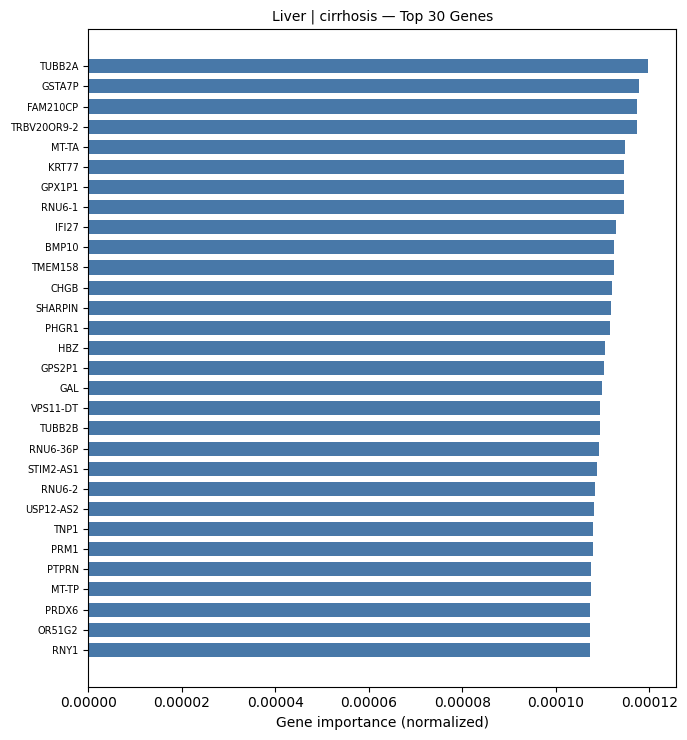

In [6]:
top = named_only(demo_imp).nlargest(TOP_N_GENES).sort_values()
labels = [gene_id_to_name.get(g, g) for g in top.index]

fig, ax = plt.subplots(figsize=(7, max(5, TOP_N_GENES * 0.25)))
ax.barh(range(len(top)), top.values, color="#4878A8", height=0.7)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Gene importance (normalized)")
ax.set_title(f"Liver | cirrhosis \u2014 Top {TOP_N_GENES} Genes", fontsize=10)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "pc_importance_top30_liver_cirrhosis.pdf", bbox_inches="tight")
plt.show()

### Importance Distribution — Liver | Cirrhosis

Histogram + cumulative importance curve — steep = concentrated, flat = diffuse.

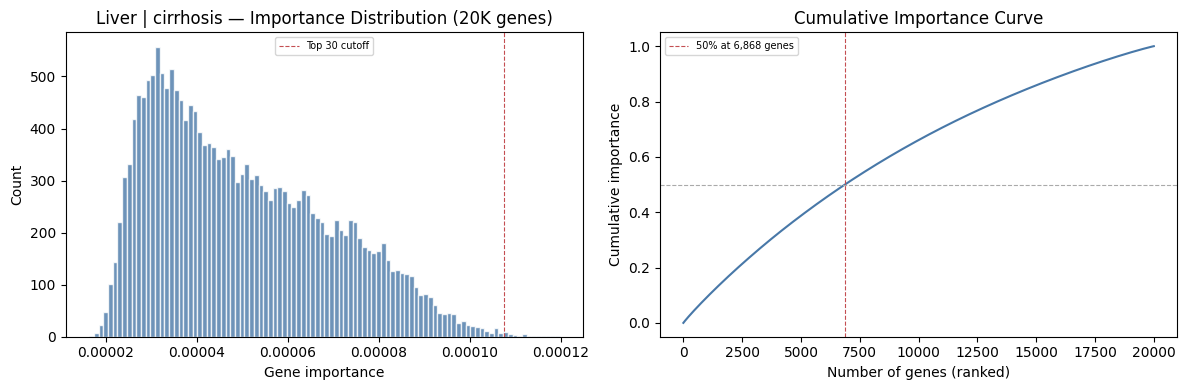

Top 30 genes hold 0.3% of total importance
Top 100 genes hold 1.1% of total importance
50% of importance reached at gene #6,868 of 20,000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of importance scores
axes[0].hist(demo_imp.values, bins=100, color="#4878A8", edgecolor="white", alpha=0.8)
axes[0].axvline(demo_imp.nlargest(30).min(), color="#C44E52", ls="--", lw=0.8, label="Top 30 cutoff")
axes[0].set_xlabel("Gene importance")
axes[0].set_ylabel("Count")
axes[0].set_title("Liver | cirrhosis — Importance Distribution (20K genes)")
axes[0].legend(fontsize=7)

# Right: cumulative importance (Lorenz-like)
sorted_imp = demo_imp.sort_values(ascending=False).values
cum_imp = np.cumsum(sorted_imp)
n_genes = len(sorted_imp)
axes[1].plot(range(1, n_genes + 1), cum_imp, color="#4878A8", lw=1.5)
axes[1].axhline(0.5, color="#AAAAAA", ls="--", lw=0.8)
# How many genes to reach 50%?
n50 = np.searchsorted(cum_imp, 0.5) + 1
axes[1].axvline(n50, color="#C44E52", ls="--", lw=0.8, label=f"50% at {n50:,} genes")
axes[1].set_xlabel("Number of genes (ranked)")
axes[1].set_ylabel("Cumulative importance")
axes[1].set_title("Cumulative Importance Curve")
axes[1].legend(fontsize=7)

fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "pc_importance_distribution_liver_cirrhosis.pdf", bbox_inches="tight")
plt.show()

print(f"Top 30 genes hold {sorted_imp[:30].sum()*100:.1f}% of total importance")
print(f"Top 100 genes hold {sorted_imp[:100].sum()*100:.1f}% of total importance")
print(f"50% of importance reached at gene #{n50:,} of {n_genes:,}")

---
## 11.4 — Scale to All Qualifying Pairs

Run the same pipeline for every qualifying pair derived from `qualified_all` above.

In [ ]:
gene_importance = {}

# Include the Liver|cirrhosis result we already computed
gene_importance[("Liver", "cirrhosis")] = demo_imp
print(f"[1/{len(qualified_all)}] Liver | cirrhosis (already done)")

remaining = qualified_all[
    ~((qualified_all["tissue"] == "Liver") & (qualified_all["category"] == "cirrhosis"))
]

for i, row in remaining.iterrows():
    tissue, category = row["tissue"], row["category"]
    idx = list(qualified_all.index).index(i) + 1
    print(f"\n[{idx + 1}/{len(qualified_all)}] {tissue} | {category}")

    _, imp = run_single_pair(tissue, category)
    gene_importance[(tissue, category)] = imp

    top5 = [gene_id_to_name.get(g, g) for g in named_only(imp).nlargest(5).index]
    print(f"  sum = {imp.sum():.4f}, top 5: {top5}")

print(f"\nDone — {len(gene_importance)} pairs.")

## 11.5 — Importance Distribution — All Pairs

Steep curve = clear biomarkers; flat = polygenic signal.

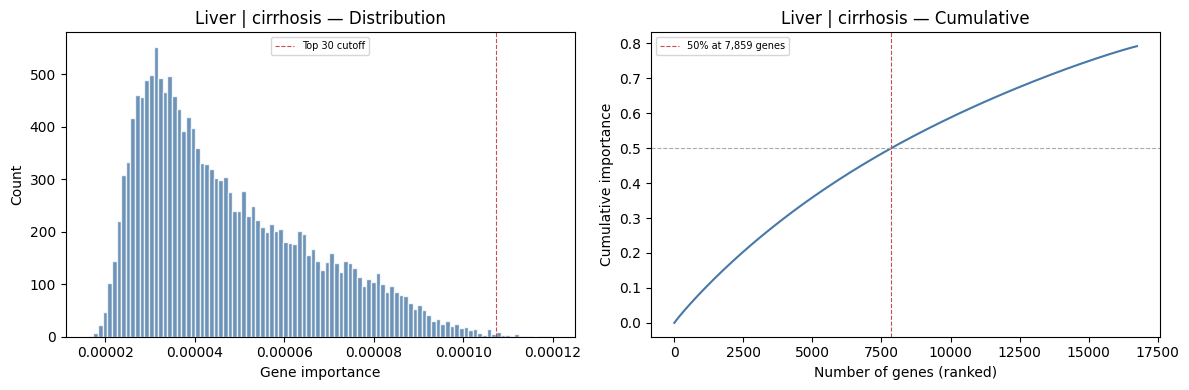

  Liver | cirrhosis: top 30 = 0.3%, top 100 = 1.1%, 50% at gene #7,859


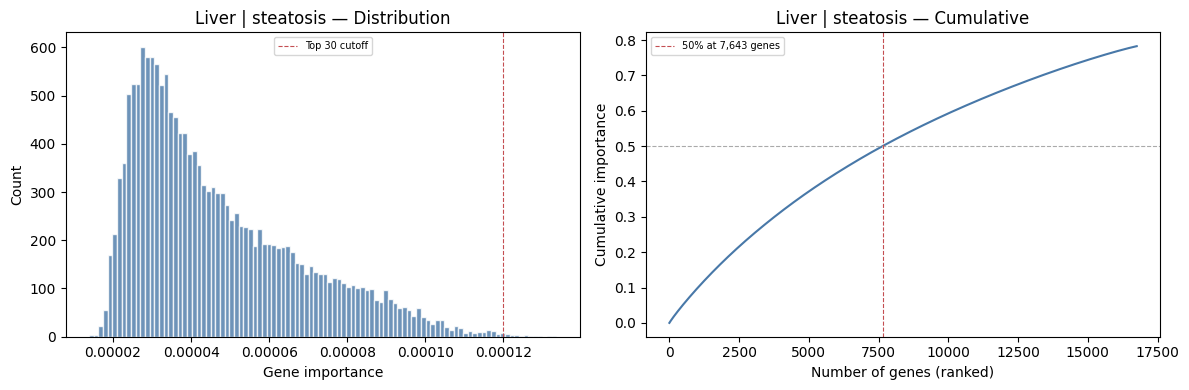

  Liver | steatosis: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #7,643


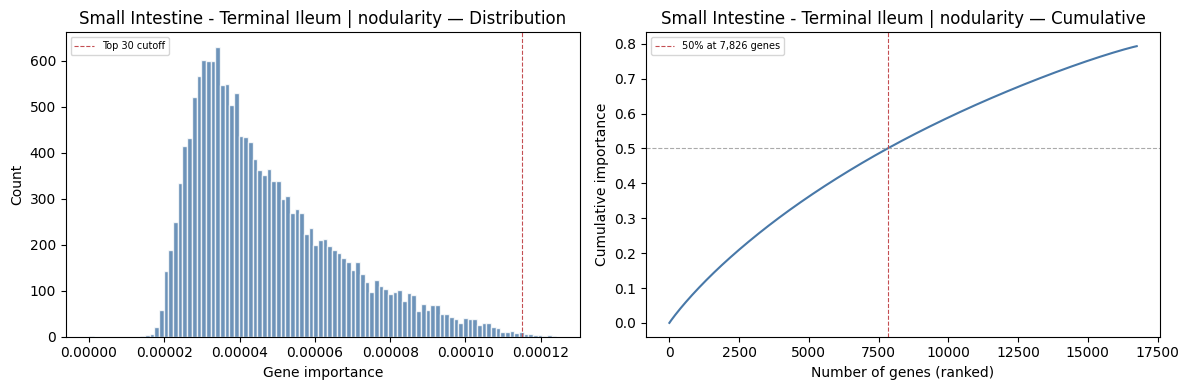

  Small Intestine - Terminal Ileum | nodularity: top 30 = 0.4%, top 100 = 1.1%, 50% at gene #7,826


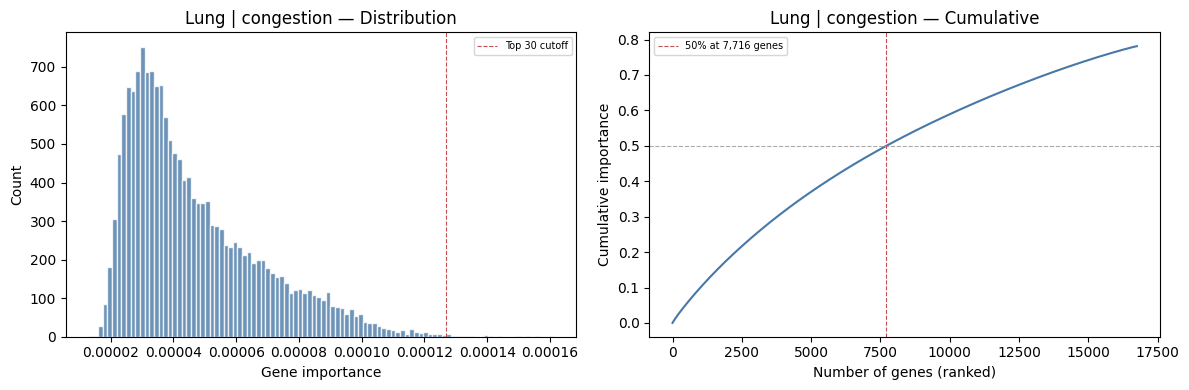

  Lung | congestion: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #7,716


In [9]:
for (tissue, category), imp_full in gene_importance.items():
    tag = f"{tissue} | {category}"
    imp = named_only(imp_full)
    sorted_imp = imp.sort_values(ascending=False).values
    cum_imp = np.cumsum(sorted_imp)
    n50 = np.searchsorted(cum_imp, 0.5) + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(imp.values, bins=100, color="#4878A8", edgecolor="white", alpha=0.8)
    axes[0].axvline(imp.nlargest(TOP_N_GENES).min(), color="#C44E52", ls="--", lw=0.8,
                     label=f"Top {TOP_N_GENES} cutoff")
    axes[0].set_xlabel("Gene importance")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"{tag} — Distribution")
    axes[0].legend(fontsize=7)

    # Cumulative
    axes[1].plot(range(1, len(sorted_imp) + 1), cum_imp, color="#4878A8", lw=1.5)
    axes[1].axhline(0.5, color="#AAAAAA", ls="--", lw=0.8)
    axes[1].axvline(n50, color="#C44E52", ls="--", lw=0.8, label=f"50% at {n50:,} genes")
    axes[1].set_xlabel("Number of genes (ranked)")
    axes[1].set_ylabel("Cumulative importance")
    axes[1].set_title(f"{tag} — Cumulative")
    axes[1].legend(fontsize=7)

    fig.tight_layout()
    plt.show()
    print(f"  {tag}: top 30 = {sorted_imp[:30].sum()*100:.1f}%, top 100 = {sorted_imp[:100].sum()*100:.1f}%, 50% at gene #{n50:,}")

## 11.6 — Top Genes — All Pairs

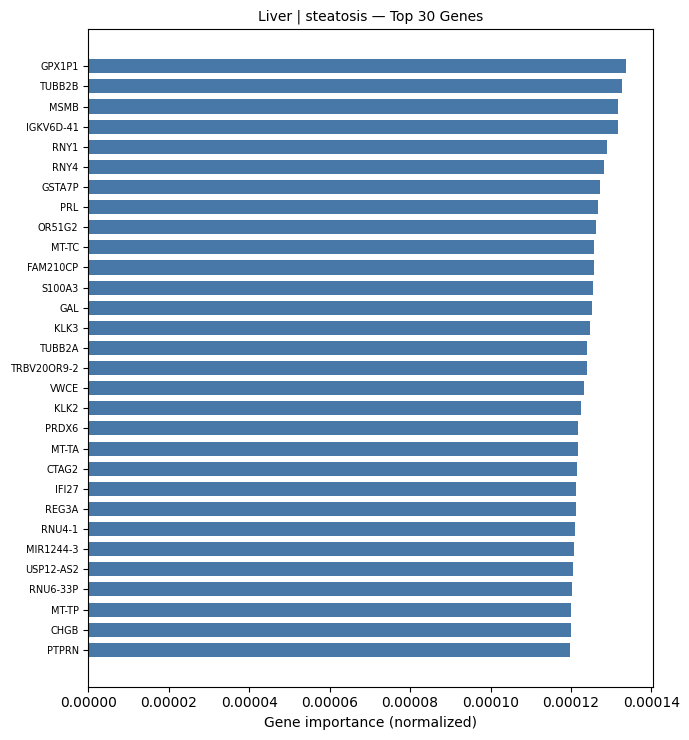

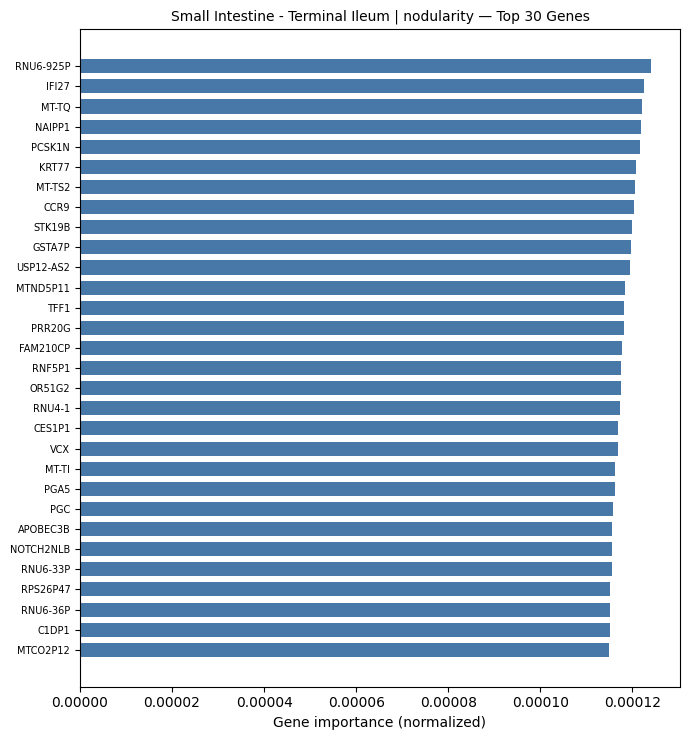

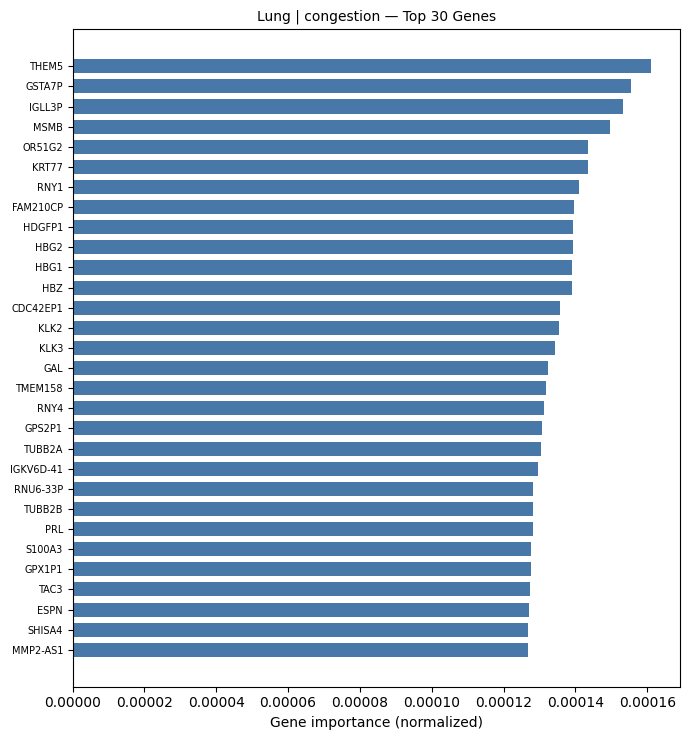

In [10]:
for (tissue, category), imp_full in gene_importance.items():
    if tissue == "Liver" and category == "cirrhosis":
        continue  # already plotted in 11.3

    imp = named_only(imp_full)
    top = imp.nlargest(TOP_N_GENES).sort_values()
    labels = [gene_id_to_name.get(g, g) for g in top.index]

    fig, ax = plt.subplots(figsize=(7, max(5, TOP_N_GENES * 0.25)))
    ax.barh(range(len(top)), top.values, color="#4878A8", height=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Gene importance (normalized)")
    ax.set_title(f"{tissue} | {category} \u2014 Top {TOP_N_GENES} Genes", fontsize=10)
    fig.tight_layout()
    plt.show()

## 11.7 — Validation: PC Importance vs Direct RF (NB07)

Spearman rank correlation between our PC-formula gene rankings and NB07's direct RF importance.

In [11]:
val_rows = []

for (tissue, category), imp in gene_importance.items():
    rf_pair = rf_fi[(rf_fi["tissue"] == tissue) & (rf_fi["category"] == category)]
    if rf_pair.empty:
        print(f"  {tissue} | {category}: no NB07 data — skipping")
        continue

    rf_direct = rf_pair.set_index("gene")["mean_importance"]
    common = imp.index.intersection(rf_direct.index)
    if len(common) < 10:
        continue

    rho, pval = spearmanr(imp[common], rf_direct[common])

    val_rows.append({
        "tissue": tissue, "category": category,
        "n_common_genes": len(common),
        "spearman_corr": rho, "p_value": pval,
    })
    print(f"  {tissue} | {category} — correlation: {rho:.3f}  (p={pval:.2e}, {len(common)} genes)")

val_df = pd.DataFrame(val_rows)
display(val_df)

  Liver | cirrhosis — correlation: 0.563  (p=1.58e-21, 241 genes)
  Liver | steatosis — correlation: 0.246  (p=2.89e-05, 283 genes)
  Small Intestine - Terminal Ileum | nodularity — correlation: 0.552  (p=7.42e-23, 269 genes)
  Lung | congestion — correlation: 0.234  (p=1.53e-04, 256 genes)


,tissue,category,n_common_genes,spearman_corr,p_value
0,Liver,cirrhosis,241,0.562716,1.577852e-21
1,Liver,steatosis,283,0.245867,2.887043e-05
2,Small Intestine - Terminal Ileum,nodularity,269,0.552021,7.420305e-23
3,Lung,congestion,256,0.234494,1.527963e-04


## 11.8 — Export

Save all 20K gene importances per qualifying pair for NB12+.

In [12]:
# Export ALL 20K genes per pair (full rankings for downstream use)
rows = []
for (tissue, category), imp in gene_importance.items():
    ranks = imp.rank(ascending=False).astype(int)
    for gene in imp.index:
        rows.append({
            "tissue": tissue, "category": category,
            "gene_id": gene,
            "gene_name": gene_id_to_name.get(gene, gene),
            "importance": imp[gene],
            "rank": ranks[gene],
        })

export_df = pd.DataFrame(rows).sort_values(["tissue", "category", "rank"]).reset_index(drop=True)
# Drop unannotated ENSG-prefixed entries (no HGNC symbol)
export_df = export_df[~export_df["gene_name"].str.startswith("ENSG")].reset_index(drop=True)
# Re-rank per pair after the drop so rank is contiguous (1..N_named)
export_df["rank"] = export_df.groupby(["tissue","category"])["importance"].rank(ascending=False, method="first").astype(int)
export_df = export_df.sort_values(["tissue", "category", "rank"]).reset_index(drop=True)
out_path = Config.TABLES_DIR / "pc_gene_importance_full.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved {len(export_df)} rows ({len(gene_importance)} pairs × {len(export_df)//len(gene_importance):,} named genes) to {out_path}")
display(export_df.head(10))

if not val_df.empty:
    val_df.to_csv(Config.TABLES_DIR / "validation_pc_vs_rf.csv", index=False)
    print(f"Saved validation to {Config.TABLES_DIR / 'validation_pc_vs_rf.csv'}")

Saved 67004 rows (4 pairs × 16,751 named genes) to /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/output/tables/pc_gene_importance_full.csv


,tissue,category,gene_id,gene_name,importance,rank
0,Liver,cirrhosis,ENSG00000137267.7,TUBB2A,0.000120,1
1,Liver,cirrhosis,ENSG00000237674.1,GSTA7P,0.000118,2
2,Liver,cirrhosis,ENSG00000213770.3,FAM210CP,0.000117,3
3,Liver,cirrhosis,ENSG00000205274.3,TRBV20OR9-2,0.000117,4
4,Liver,cirrhosis,ENSG00000210127.1,MT-TA,0.000115,5
5,Liver,cirrhosis,ENSG00000189182.10,KRT77,0.000115,6
6,Liver,cirrhosis,ENSG00000197582.5,GPX1P1,0.000115,7
7,Liver,cirrhosis,ENSG00000206625.1,RNU6-1,0.000114,8
8,Liver,cirrhosis,ENSG00000165949.13,IFI27,0.000113,9
9,Liver,cirrhosis,ENSG00000163217.2,BMP10,0.000112,10


Saved validation to /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/output/tables/validation_pc_vs_rf.csv
